In [3]:
import pandas as pd
import plotly.express as px

In [8]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
df = df.drop_duplicates()

print("Duplicates removed successfully")


Duplicates removed successfully


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date conversion completed")

Date conversion completed


In [13]:
df['Month'] = df['Order Date'].dt.month_name()

df['Year'] = df['Order Date'].dt.year

print("Month and Year columns created")

Month and Year columns created


In [14]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales

,Month,Sales
0,April,137762.1286
1,August,159044.0630
2,December,325293.5035
3,February,59751.2514
4,January,94924.8356
5,July,147238.0970
6,June,152718.6793
7,March,205005.4888
8,May,155028.8117
9,November,352461.0710


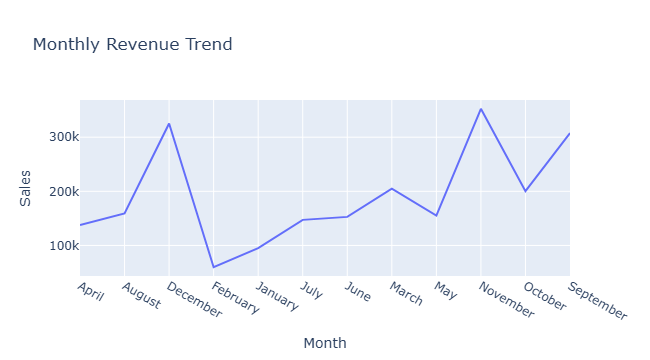

In [15]:
import plotly.express as px

fig = px.line(
    monthly_sales,
    x='Month',
    y='Sales',
    title='Monthly Revenue Trend'
)

fig.show()

In [16]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

category_sales

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


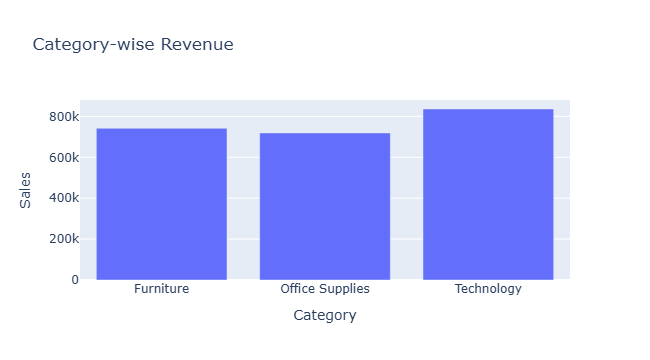

In [17]:
fig = px.bar(
    category_sales,
    x='Category',
    y='Sales',
    title='Category-wise Revenue'
)

fig.show()

In [20]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()

top_products = top_products.sort_values(by='Sales', ascending=False)

top_products = top_products.head(10)

top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


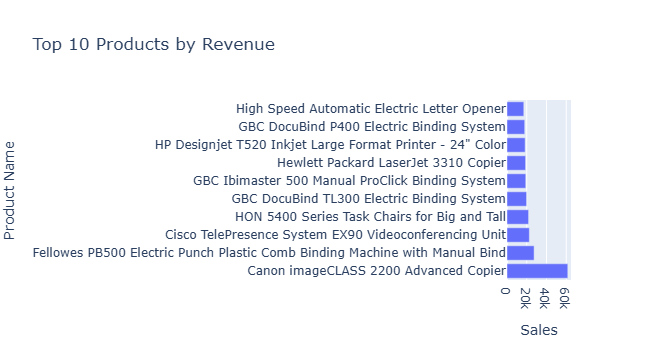

In [21]:
fig = px.bar(
    top_products,
    x='Sales',
    y='Product Name',
    title='Top 10 Products by Revenue',
    orientation='h'
)

fig.show()

In [22]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

region_sales

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


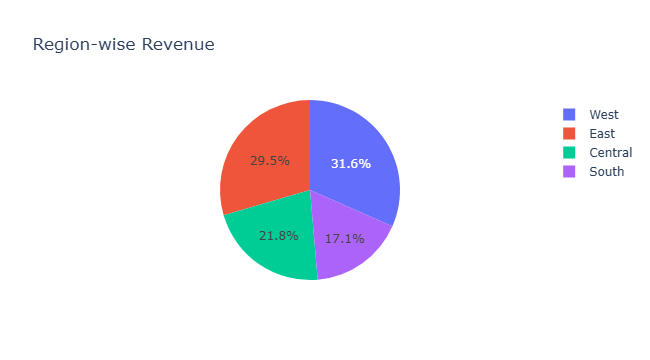

In [23]:
fig = px.pie(
    region_sales,
    names='Region',
    values='Sales',
    title='Region-wise Revenue'
)

fig.show()

In [24]:
year_sales = df.groupby('Year')['Sales'].sum().reset_index()

year_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


In [25]:
year_sales['YOY Growth %'] = year_sales['Sales'].pct_change() * 100

year_sales

,Year,Sales,YOY Growth %
0,2014,484247.4981,NaN
1,2015,470532.5090,-2.832227
2,2016,609205.5980,29.471521
3,2017,733215.2552,20.355962


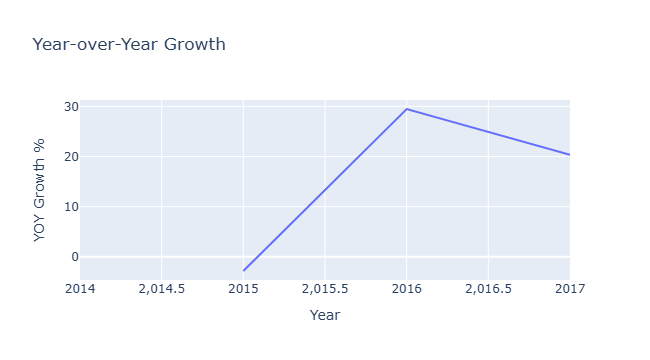

In [26]:
fig = px.line(
    year_sales,
    x='Year',
    y='YOY Growth %',
    title='Year-over-Year Growth'
)

fig.show()

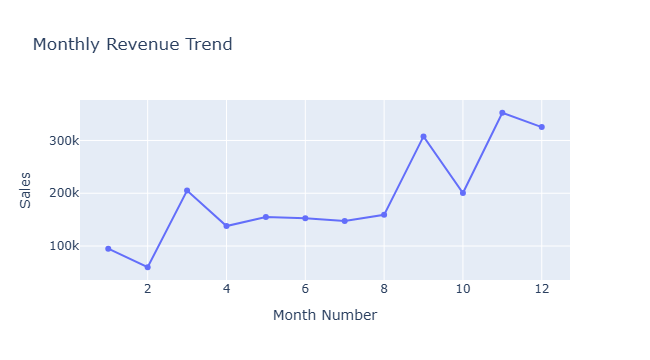

In [27]:
monthly_sales_order = df.groupby(df['Order Date'].dt.month)['Sales'].sum().reset_index()

monthly_sales_order.columns = ['Month Number', 'Sales']

fig = px.line(
    monthly_sales_order,
    x='Month Number',
    y='Sales',
    title='Monthly Revenue Trend',
    markers=True
)

fig.show()

In [28]:
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()

profit_by_category

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


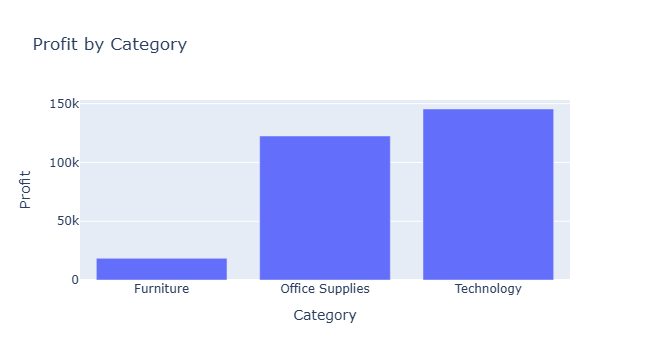

In [29]:
fig = px.bar(
    profit_by_category,
    x='Category',
    y='Profit',
    title='Profit by Category'
)

fig.show()